<a href="https://colab.research.google.com/github/nkefeyan-22-26/ECON5200-Applied-Data-Analytics-in-Economics/blob/main/Assignment5/Assignment%205%3A%20The%20Sovereign%20Risk%20Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install wbgapi scikit-learn statsmodels matplotlib seaborn numpy pandas

## The Mission:
The International Monetary Fund’s Global Financial Stability Division is building a next-generation Early Warning System (EWS) to identify emerging-market economies at elevated risk of economic crisis. The existing model — a brute-force OLS regression using 30+ World Development Indicators — is failing catastrophically: it achieves near-perfect fit on historical data yet produces dangerously inaccurate forecasts for new countries. The Director suspects overfitting. Meanwhile, the Division Chief needs a binary classifier that answers a single operational question every quarter: “Will this country experience a growth crisis within the next five years?”

Your mandate is to diagnose the existing model’s failure using bias-variance analysis, rebuild the forecasting engine with Ridge and Lasso regularization, construct a logistic regression crisis classifier, and evaluate it using the full toolkit of classification metrics under real IMF operational constraints — where a missed crisis triggers a sovereign default and a false alarm depletes scarce emergency lending capacity.



In [7]:
import wbgapi as wb
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Indicator codes and names
indicators = {
    'NY.GDP.PCAP.KD.ZG': 'gdp_growth_pc',
    'NY.GDP.PCAP.KD':    'gdp_per_capita',
    'FP.CPI.TOTL.ZG':    'inflation',
    'NE.EXP.GNFS.ZS':    'exports_pct_gdp',
    'NE.IMP.GNFS.ZS':    'imports_pct_gdp',
    'BX.KLT.DINV.WD.GD.ZS': 'fdi_pct_gdp',
    'GC.DOD.TOTL.GD.ZS': 'govt_debt_pct_gdp',
    'GC.REV.XGRT.GD.ZS': 'govt_revenue_pct_gdp',
    'BN.CAB.XOKA.GD.ZS': 'current_account_pct_gdp',
    'FM.LBL.BMNY.GD.ZS': 'broad_money_pct_gdp',
    'FS.AST.DOMO.GD.ZS': 'domestic_credit_pct_gdp',
    'SL.UEM.TOTL.ZS':    'unemployment_rate',
    'SP.POP.TOTL':       'population',
    'SP.URB.TOTL.IN.ZS': 'urban_population_pct',
    'SP.DYN.LE00.IN':    'life_expectancy',
    'SE.ADT.LITR.ZS':    'adult_literacy_rate',
    'SE.XPD.TOTL.GD.ZS': 'edu_expenditure_pct_gdp',
    'SH.XPD.CHEX.GD.ZS': 'health_expenditure_pct_gdp',
    'IT.NET.USER.ZS':    'internet_users_pct',
    'EG.USE.ELEC.KH.PC': 'electricity_use_pc',
    'AG.LND.ARBL.ZS':    'arable_land_pct',
    'TX.VAL.MANF.ZS.UN': 'manufactures_exports_pct',
    'NV.AGR.TOTL.ZS':    'agriculture_value_added_pct',
    'NV.IND.TOTL.ZS':    'industry_value_added_pct',
    'NV.SRV.TOTL.ZS':    'services_value_added_pct',
    'MS.MIL.XPND.GD.ZS': 'military_expenditure_pct_gdp',
    # 'IC.BUS.EASE.XQ':    'ease_of_business_score', # This indicator is discontinued and causes errors
    'TG.VAL.TOTL.GD.ZS': 'trade_pct_gdp',
    'SP.POP.GROW':       'population_growth',
    'ER.GDP.FWTL.M3.KD': 'water_productivity',
}

# Download each indicator separately, average across 2013-2019, then merge
dfs = []
for code, name in indicators.items():
    temp = wb.data.DataFrame(code, time=range(2013, 2020), skipBlanks=True, labels=False)
    temp = temp.mean(axis=1).reset_index()
    temp.columns = ['country', name]
    dfs.append(temp)

df = dfs[0]
for d in dfs[1:]:
    df = df.merge(d, on='country', how='outer')

# Drop countries missing more than 40% of indicators
min_indicators = len(indicators) * 0.6
df = df.dropna(thresh=int(min_indicators))

# Drop indicators missing more than 40% of countries
min_countries = len(df) * 0.6
df = df.dropna(axis=1, thresh=int(min_countries))

# Median impute remaining missing values
for col in df.columns:
    if col != 'country':
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)

# Define continuous and binary outcomes
df['crisis'] = (df['gdp_growth_pc'] < 0).astype(int)

# Separate features, regression target, and classification target
feature_cols = [c for c in df.columns if c not in ['country', 'gdp_growth_pc', 'crisis']]
X = df[feature_cols]
y_reg = df['gdp_growth_pc']
y_cls = df['crisis']

# 70/30 train-test split
X_train, X_test, y_train_reg, y_test_reg, y_train_cls, y_test_cls = train_test_split(
    X, y_reg, y_cls, test_size=0.30, random_state=42
)

# Standardize using scaler fit on training data only
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=feature_cols)

# Print summary
print(f"Dataset shape: {df.shape}")
print(f"Number of features: {len(feature_cols)}")
print(f"Train size: {len(X_train_scaled)}")
print(f"Test size: {len(X_test_scaled)}")
print(f"Crisis countries: {y_cls.sum()}")
print(f"Non-crisis: {(y_cls == 0).sum()}")
print(f"Crisis base rate: {y_cls.mean():.3f}")
df.head

Dataset shape: (246, 29)
Number of features: 26
Train size: 172
Test size: 74
Crisis countries: 41
Non-crisis: 205
Crisis base rate: 0.167


<bound method NDFrame.head of     country  gdp_growth_pc  gdp_per_capita  inflation  exports_pct_gdp  \
0       ABW       2.245502    28023.816193   0.635452        70.441004   
1       AFE       0.223588     1489.277423   5.404875        25.343865   
2       AFG      -0.272302      565.564058   3.383775        31.663522   
3       AFW       0.649231     1827.336197   1.902643        31.663522   
4       AGO      -2.476583     3452.648446  17.523280        33.131172   
..      ...            ...             ...        ...              ...   
260     XKX       4.894998     3688.666776   1.021507        25.500637   
261     YEM      -8.967806     1451.301609   9.536584        12.691469   
262     ZAF      -0.206104     6115.606201   5.261930        27.898410   
263     ZMB       0.479478     1301.490806   9.426725        37.050666   
264     ZWE       0.035122     1395.305379  37.754335        22.230421   

     imports_pct_gdp  fdi_pct_gdp  govt_revenue_pct_gdp  \
0          73.145673     3.551600             23.581462   
1          29.927302     1.994010             21.596761   
2          35.721134     0.415848             10.773546   
3          35.721134     2.024465             23.581462   
4          26.043190    -1.996599             20.665147   
..               ...          ...                   ...   
260        53.598995     4.155577             23.581462   
261        30.850506    -0.834732             23.581462   
262        28.227591     1.132043             28.735118   
263        38.054882     4.548347             18.037190   
264        31.624108     1.515235             12.568245   

     current_account_pct_gdp  broad_money_pct_gdp  ...  arable_land_pct  \
0                  -0.669091            73.467045  ...        11.111111   
1                  -2.814634            45.569394  ...         8.096816   
2                 -19.805290            35.210065  ...        11.900053   
3                  -2.814634            54.856696  ...        11.932068   
4                   0.248949            30.969661  ...         4.166084   
..                       ...                  ...  ...              ...   
260                -6.549505            44.977839  ...        10.290698   
261                -5.520737            34.740937  ...         2.185189   
262                -3.584226            66.146228  ...         9.892094   
263                -1.792251            22.327261  ...         5.034850   
264                -5.575959            18.767572  ...        10.447380   

     manufactures_exports_pct  agriculture_value_added_pct  \
0                   32.913314                     0.018337   
1                   34.921858                    12.439481   
2                    9.095852                    23.651344   
3                   12.793712                    20.565694   
4                    1.594801                    12.971708   
..                        ...                          ...   
260                 41.270762                     7.679652   
261                  4.739296                    22.727436   
262                 44.854639                     2.200798   
263                 12.779060                     5.205943   
264                 13.391911                     9.903018   

     industry_value_added_pct  services_value_added_pct  \
0                   11.730514                 79.273706   
1                   26.027637                 53.740973   
2                   15.966050                 55.887343   
3                   25.032198                 50.704930   
4                   41.287587                 44.822695   
..                        ...                       ...   
260                 27.147180                 46.251762   
261                 31.669690                 41.602874   
262                 23.877357                 64.144630   
263                 34.395194                 53.999310   
264                 27.717361                 54.377272   

     military_exp

In [8]:
# 1.1
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Fit OLS on all standardized predictors
ols = LinearRegression()
ols.fit(X_train_scaled, y_train_reg)

# Compute R² on train and test
r2_train = ols.score(X_train_scaled, y_train_reg)
r2_test  = ols.score(X_test_scaled,  y_test_reg)
gap      = r2_train - r2_test

# Compute predictor-to-observation ratio
p = X_train_scaled.shape[1]
n = X_train_scaled.shape[0]
pn_ratio = p / n

print(f"Training R²:    {r2_train:.4f}")
print(f"Test R²:        {r2_test:.4f}")
print(f"Train-Test Gap: {gap:.4f}")
print(f"p/n ratio:      {pn_ratio:.4f}  ({p} predictors, {n} observations)")

Training R²:    0.4832
Test R²:        0.1650
Train-Test Gap: 0.3182
p/n ratio:      0.1512  (26 predictors, 172 observations)


26 predictors and 172 training observations. The model has a p/n ratio of 0.15, meaning for every predictor, there are ~6.6 observations. This ratio isn't exterme, but the OLS still takes 26 degrees of freedom to fit coefs. This inflates the training R^2 to .48, while the test R^2 is shrunken to .17. The gap between these shows high variance. The model is too fit to the training set to generalize.

In [9]:
# 1.2
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error
import numpy as np

# Fit RidgeCV (5-fold cross validation)
ridge = RidgeCV(cv=5)
ridge.fit(X_train_scaled, y_train_reg)

# Fit LassoCV (5-fold cross-validation)
lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_train_scaled, y_train_reg)

models = {
    'OLS':   ols,
    'Ridge': ridge,
    'Lasso': lasso
}

results = []
for name, model in models.items():
    train_r2  = model.score(X_train_scaled, y_train_reg)
    test_r2   = model.score(X_test_scaled,  y_test_reg)
    test_rmse = np.sqrt(mean_squared_error(y_test_reg, model.predict(X_test_scaled)))

    if name == 'OLS':
        alpha     = None
        nonzero   = X_train_scaled.shape[1]
    elif name == 'Ridge':
        alpha     = ridge.alpha_
        nonzero   = np.sum(ridge.coef_ != 0)
    else:
        alpha     = lasso.alpha_
        nonzero   = np.sum(lasso.coef_ != 0)

    results.append({
        'Model':            name,
        'Lambda*':          alpha,
        'Non-zero Coefs':   nonzero,
        'Training R²':      round(train_r2,  4),
        'Test R²':          round(test_r2,   4),
        'Test RMSE':        round(test_rmse, 4)
    })

comparison_table = pd.DataFrame(results)
print(comparison_table.to_string(index=False))

Model   Lambda*  Non-zero Coefs  Training R²  Test R²  Test RMSE
  OLS       NaN              26       0.4832   0.1650     2.5405
Ridge 10.000000              26       0.4668   0.1188     2.6098
Lasso  0.122848              12       0.3683   0.3048     2.3181


Recommendation: Lasso

Despite having a lower training R², the Lasso has the best test R² (0.30) and lowest test RMSE (2.32), meaning it can generalize best to unseen countries.

Both Ridge and Lasso have bias by shrining coefs toward zero which sacrifices some of the training fit, but this reduces the variance enough that the performance of the test improves. Lasso does better than Ridge by shrinking 14 coefs to 0 (12 predictors left in the model).

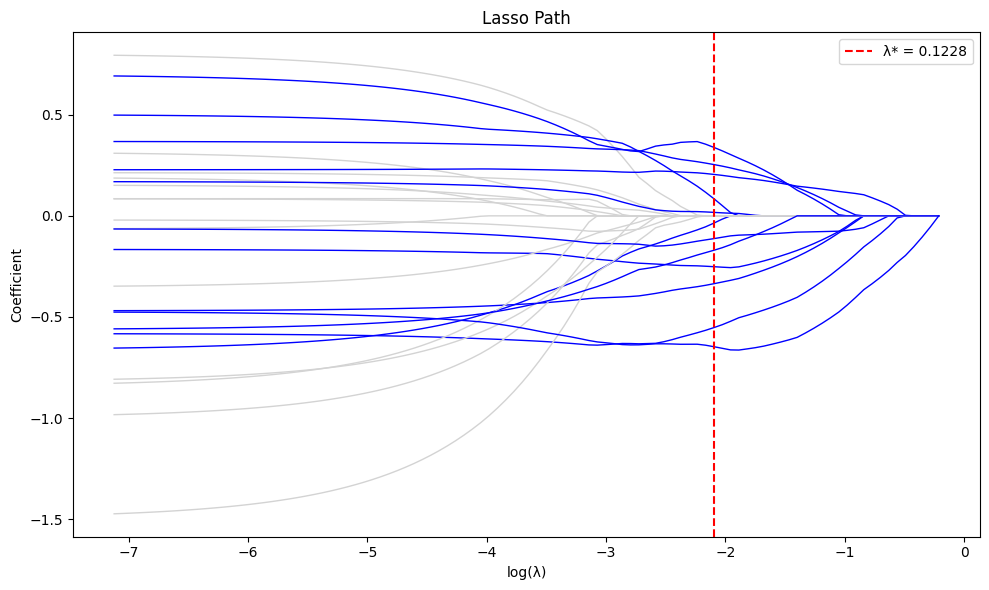

First predictor to enter: population_growth


In [18]:
from sklearn.linear_model import lasso_path
import matplotlib.pyplot as plt
import numpy as np

# Compute lasso path
alphas, coefs, _ = lasso_path(X_train_scaled, y_train_reg)

# Get the CV-selected lambda
best_alpha = lasso.alpha_

# Identify which coefficients are non-zero at best_alpha
best_alpha_idx = np.argmin(np.abs(alphas - best_alpha))
nonzero_mask   = coefs[:, best_alpha_idx] != 0

# Plot lasso path
plt.figure(figsize=(10, 6))

for i in range(coefs.shape[0]):
    color = 'blue' if nonzero_mask[i] else 'lightgray'
    plt.plot(np.log(alphas), coefs[i], color=color, linewidth=1)

plt.axvline(np.log(best_alpha), color='red', linestyle='--', label=f'λ* = {best_alpha:.4f}')
plt.xlabel('log(λ)')
plt.ylabel('Coefficient')
plt.title('Lasso Path')
plt.legend()
plt.tight_layout()
plt.show()

# Identify first predictor to enter (non-zero at highest lambda)
first_entry_idx = None
for j in range(coefs.shape[1]):
    nonzero = np.where(coefs[:, j] != 0)[0]
    if len(nonzero) > 0:
        first_entry_idx = nonzero[0]
        break

print(f"First predictor to enter: {feature_cols[first_entry_idx]}")

Population growth is probably the strongest unconditional predictor of cross-country GDP/capita growth because rapid population growth dilutes per capita output. Even if total GDP increases, income per person can stay the same or go down. This is consistent across countries and time periods.

Just because Lasso zeros life_expectency, that doesn't mean that health doesn't affect economic growth. It simply means that life expectancy has predictive redundancy given the other indicators in the model. Life expectancy is highly correlated with other variables like GDP/capita, edu, and health expenditure. So, it being dropped shows its correlation with the rest of the data.

**Context shift: The Division Chief does not want a continuous GDP growth forecast. She needs a binary early warning signal: will this country experience a growth crisis (sustained negative growth) or not? This transforms the problem from regression to classification. Use the crisis indicator you constructed in the data pipeline.**

In [11]:
# 2.1
# Get the features selected by Lasso (non-zero coefficients)
lasso_selected = [feature_cols[i] for i in range(len(feature_cols)) if lasso.coef_[i] != 0]

# Fit OLS on binary crisis outcome using Lasso-selected features
lpm = LinearRegression()
lpm.fit(X_train_scaled[lasso_selected], y_train_cls)

# Generate predicted values on test set
lpm_preds = lpm.predict(X_test_scaled[lasso_selected])

# Count predictions outside [0, 1]
below_zero = np.sum(lpm_preds < 0)
above_one  = np.sum(lpm_preds > 1)

print(f"Predictions below 0: {below_zero}")
print(f"Predictions above 1: {above_one}")
print(f"Total out of bounds: {below_zero + above_one}")
print(f"Min prediction: {lpm_preds.min():.4f}")
print(f"Max prediction: {lpm_preds.max():.4f}")

Predictions below 0: 10
Predictions above 1: 0
Total out of bounds: 10
Min prediction: -0.1977
Max prediction: 0.5443


Predicted probabilities outside 0 and 1 are an issue because probabilities cannot be negative. As the IMF, getting this probability is useless and breaks decision-making. Any threshold-based flagging system will misclassify these countries and the model can't be used to rank or compare crisis risk.

In [12]:
from sklearn.linear_model import LogisticRegression

# Fit logistic regression on Lasso-selected features
logit = LogisticRegression(random_state=42)
logit.fit(X_train_scaled[lasso_selected], y_train_cls)

# Coefficients and intercept
coef_df = pd.DataFrame({
    'Feature':    lasso_selected,
    'Beta':       logit.coef_[0],
    'Odds Ratio': np.exp(logit.coef_[0])
})
coef_df = coef_df.reindex(coef_df['Odds Ratio'].abs().sort_values(ascending=False).index)

print(f"Intercept: {logit.intercept_[0]:.4f}")
print(coef_df)

# Verify predicted probabilities are within [0, 1]
probs = logit.predict_proba(X_test_scaled[lasso_selected])[:, 1]
print(f"\nMin predicted probability: {probs.min():.4f}")
print(f"Max predicted probability: {probs.max():.4f}")

Intercept: -2.1483
                         Feature      Beta  Odds Ratio
5           urban_population_pct  0.742217    2.100587
3              unemployment_rate  0.477433    1.611932
10             population_growth  0.321575    1.379299
0                 gdp_per_capita  0.217382    1.242819
1                      inflation  0.106920    1.112845
9   military_expenditure_pct_gdp  0.082350    1.085836
11            water_productivity  0.079165    1.082383
8       manufactures_exports_pct -0.169874    0.843771
4                     population -0.368671    0.691653
2                imports_pct_gdp -0.406537    0.665953
6                life_expectancy -0.533888    0.586321
7                arable_land_pct -0.656765    0.518526

Min predicted probability: 0.0024
Max predicted probability: 0.6675


**urban_population_pct has athe largest absolute odds - OR of 2.10.
For a policy**

For a non-technical policy briefing, I'd say that a one Stdev increase in urban population multiplies the odds of a crisis by 2.1 times, all else being held constant. Urbanized emerging market economies are more exposed to wage pressurs, dependence on imports, and financial contagion which can cause the economy to shrink.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


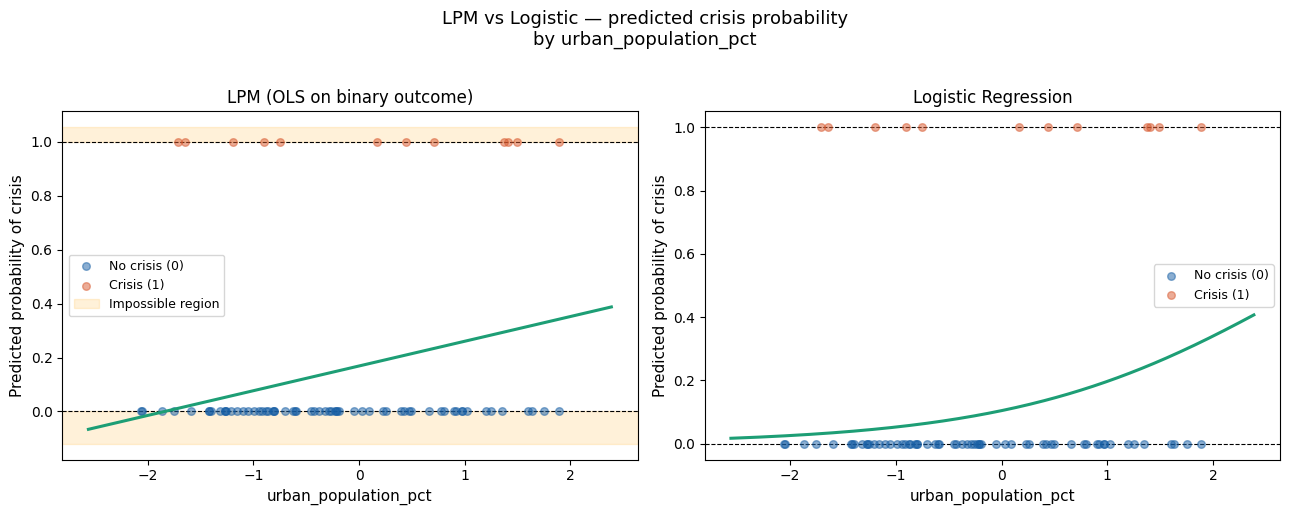

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Convert to numpy arrays
X_train_arr = X_train_scaled[lasso_selected].values
X_test_arr  = X_test_scaled[lasso_selected].values
y_test_arr  = y_test_cls.values

# Get index of strongest predictor
top_idx  = lasso_selected.index(strongest)
x_col    = X_test_arr[:, top_idx]
x_smooth = np.linspace(x_col.min() - 0.5, x_col.max() + 0.5, 300)

# Build full feature matrix holding all other features at 0 (mean)
X_smooth_full = np.zeros((300, X_train_arr.shape[1]))
X_smooth_full[:, top_idx] = x_smooth

lpm_line   = lpm.predict(X_smooth_full)
logit_line = logit.predict_proba(X_smooth_full)[:, 1]

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, line, title in zip(
    axes,
    [lpm_line, logit_line],
    ['LPM (OLS on binary outcome)', 'Logistic Regression']
):
    ax.scatter(x_col[y_test_arr == 0], y_test_arr[y_test_arr == 0],
               color='#185FA5', alpha=0.5, s=30, label='No crisis (0)', zorder=3)
    ax.scatter(x_col[y_test_arr == 1], y_test_arr[y_test_arr == 1],
               color='#D85A30', alpha=0.5, s=30, label='Crisis (1)', zorder=3)
    ax.axhline(0, color='black', lw=0.8, linestyle='--')
    ax.axhline(1, color='black', lw=0.8, linestyle='--')
    ax.plot(x_smooth, line, color='#1D9E75', lw=2.2, zorder=4)
    ax.set_xlabel(strongest, fontsize=11)
    ax.set_ylabel('Predicted probability of crisis', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=9)

# Shade impossible regions on LPM panel only
y_min = axes[0].get_ylim()[0]
y_max = axes[0].get_ylim()[1]
axes[0].axhspan(y_min, 0, alpha=0.15, color='orange', label='Impossible region')
axes[0].axhspan(1, y_max, alpha=0.15, color='orange')
axes[0].legend(fontsize=9)

plt.suptitle(f'LPM vs Logistic — predicted crisis probability\nby {strongest}', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Phase 3

In [21]:
# Compute crisis base rate in test set
base_rate = y_test_cls.mean()

# Naive baseline: always predict no crisis
naive_preds = np.zeros(len(y_test_cls))
naive_acc   = np.mean(naive_preds == y_test_cls)
naive_recall = 0.0

# Logistic regression at default threshold 0.5
logit_preds = logit.predict(X_test_scaled[lasso_selected])
logit_acc   = np.mean(logit_preds == y_test_cls)

from sklearn.metrics import recall_score
logit_recall = recall_score(y_test_cls, logit_preds)

print(f"Crisis base rate: {base_rate:.3f}")
print(f"Naive baseline accuracy: {naive_acc:.3f}")
print(f"Naive baseline recall: {naive_recall:.3f}")
print(f"Logistic accuracy: {logit_acc:.3f}")
print(f"Logistic recall: {logit_recall:.3f}")

Crisis base rate: 0.162
Naive baseline accuracy: 0.838
Naive baseline recall: 0.000
Logistic accuracy: 0.865
Logistic recall: 0.333


A naive model will always predict "no crisis" will be accurate 83.8% of the time. This is higher than the logisitic regression's 86.5%, while catching zero crises. If we reported accuracy alone to the head of the division, the model will show improvement but it would not show that the naive baseline catches nothing. This causes a paradox, when the minority class makes up only 16.2% of observations, accuracy is driven by correct "no crisis" prediction and hides the model's failiure to catch the right crises.

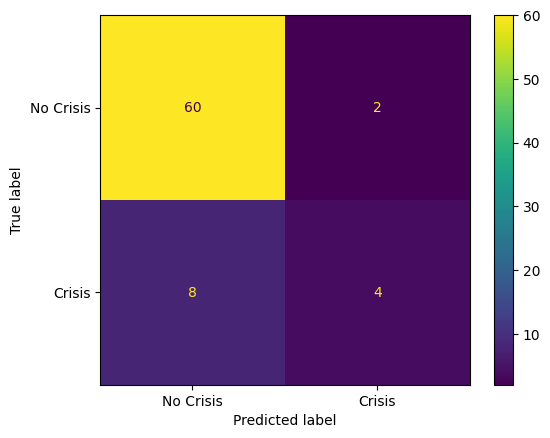

              precision    recall  f1-score   support

   No Crisis       0.88      0.97      0.92        62
      Crisis       0.67      0.33      0.44        12

    accuracy                           0.86        74
   macro avg       0.77      0.65      0.68        74
weighted avg       0.85      0.86      0.85        74

True Positives  (crises correctly flagged): 4
False Negatives (crises missed): 8
False Positives (false alarms): 2
True Negatives  (correct no-crisis): 60


In [22]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report

# Confusion matrix at default threshold 0.5
cm = confusion_matrix(y_test_cls, logit_preds)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Crisis', 'Crisis'])
disp.plot()
plt.show()

# Full classification report
print(classification_report(y_test_cls, logit_preds, target_names=['No Crisis', 'Crisis']))

# Extract individual values
tn, fp, fn, tp = cm.ravel()
print(f"True Positives  (crises correctly flagged): {tp}")
print(f"False Negatives (crises missed): {fn}")
print(f"False Positives (false alarms): {fp}")
print(f"True Negatives  (correct no-crisis): {tn}")

For the IMF, False negatives are more costly than false positives. Missing a real crisis risks sovereign default and 50 billion dollars, while a false alarm only wastes 2 million dollars and some diplomacy issues. At the default threshold at .5, the model misses 8/12 crises. This could be dangerous. The head of the division should prioritize recall over Precision. It's better to overflag and waste some missions than to underflag and miss a sovereign default.

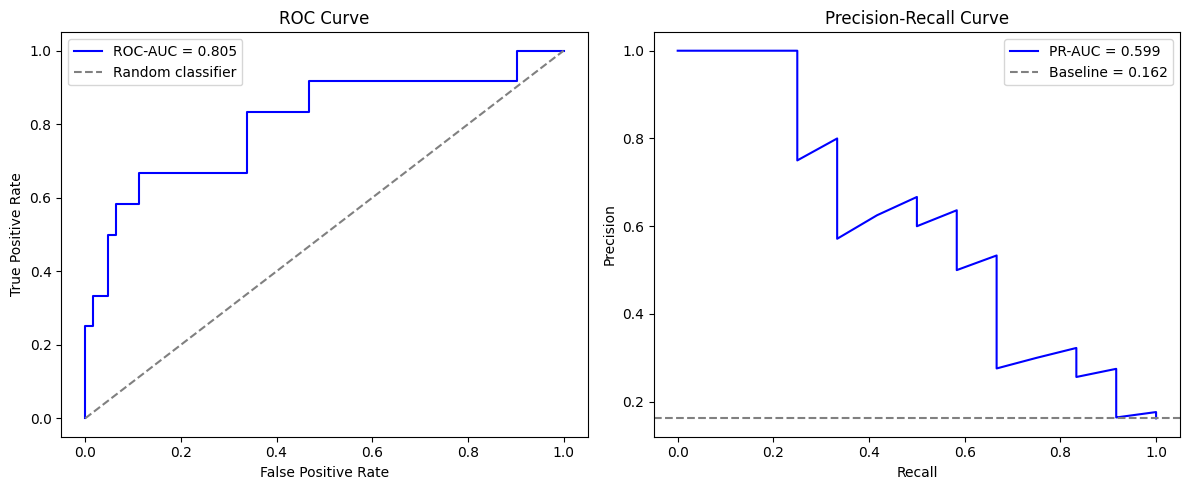

ROC-AUC: 0.805
PR-AUC:  0.599


In [23]:
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, auc

# Get predicted probabilities
probs = logit.predict_proba(X_test_scaled[lasso_selected])[:, 1]

# Compute ROC curve
fpr, tpr, _ = roc_curve(y_test_cls, probs)
roc_auc     = roc_auc_score(y_test_cls, probs)

# Compute Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_test_cls, probs)
pr_auc               = auc(recall, precision)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC panel
axes[0].plot(fpr, tpr, color='blue', label=f'ROC-AUC = {roc_auc:.3f}')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random classifier')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

# PR panel
axes[1].plot(recall, precision, color='blue', label=f'PR-AUC = {pr_auc:.3f}')
axes[1].axhline(y_test_cls.mean(), color='gray', linestyle='--', label=f'Baseline = {y_test_cls.mean():.3f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"ROC-AUC: {roc_auc:.3f}")
print(f"PR-AUC:  {pr_auc:.3f}")

The ROC-AUC of 0.805 is notably higher than the PR-AUC of 0.599 because ROC-AUC rewards the model for correctly ranking the 62 non-crisis countries as low-risk — the abundance of True Negatives inflates the metric by keeping the False Positive Rate low even at moderate thresholds. PR-AUC ignores True Negatives entirely and focuses only on how well the model identifies the 12 actual crisis countries, which is a much harder task given their rarity. For the IMF's crisis detection mission, the PR curve is more informative — a model that looks strong on ROC can still fail badly at the specific job of flagging the minority of countries that actually need intervention.

Capacity-constrained threshold:0.55
Countries flagged:5
Precision at capacity tau:0.800
Recall at capacity tau:0.333

F1-optimal threshold:0.27
F1 at optimal threshold:0.609


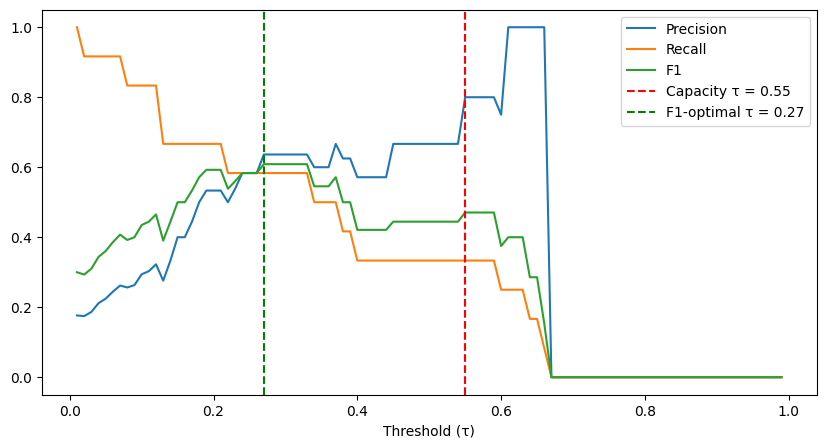

In [26]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Sweep thresholds from 0.01 to 0.99
thresholds = np.arange(0.01, 1.00, 0.01)

precisions=[]
recalls=[]
f1s=[]
n_flagged=[]

for t in thresholds:
    preds = (probs >= t).astype(int)
    n_flagged.append(preds.sum())
    precisions.append(precision_score(y_test_cls, preds, zero_division=0))
    recalls.append(recall_score(y_test_cls, preds, zero_division=0))
    f1s.append(f1_score(y_test_cls, preds, zero_division=0))

# Find capacity-constrained threshold (flags at most 5 countries)
capacity_idx = next(i for i, n in enumerate(n_flagged) if n <= 5)
capacity_tau = thresholds[capacity_idx]

# Find F1-optimal threshold
f1_idx  = np.argmax(f1s)
f1_tau  = thresholds[f1_idx]

# Print results
print(f"Capacity-constrained threshold:{capacity_tau:.2f}")
print(f"Countries flagged:{n_flagged[capacity_idx]}")
print(f"Precision at capacity tau:{precisions[capacity_idx]:.3f}")
print(f"Recall at capacity tau:{recalls[capacity_idx]:.3f}")
print(f"\nF1-optimal threshold:{f1_tau:.2f}")
print(f"F1 at optimal threshold:{f1s[f1_idx]:.3f}")

# Plot
plt.figure(figsize=(10, 5))
plt.plot(thresholds, precisions,label='Precision')
plt.plot(thresholds, recalls,label='Recall')
plt.plot(thresholds, f1s, label='F1')
plt.axvline(capacity_tau, color='red', linestyle='--', label=f'Capacity τ = {capacity_tau:.2f}')
plt.axvline(f1_tau,color='green',linestyle='--', label=f'F1-optimal τ = {f1_tau:.2f}')
plt.xlabel('Threshold (τ)')
plt.ylabel
plt.legend()

Recommendation: IMF adopts the F1-optimal threshold (τ = 0.27) - this balances the cost of missed crises against false alarms better than the alternative. At this threshold, the model will Recall about .6, meaning that 7/12 of the crises we would catch and we would miss 5. At τ = .55 only flags 5 countries with higher precision but catches only 4 crisis countrys, missing 8/12. The F1-optimal threshold will trigger more missions than the staffing limit of 5, but it is still recommended that high-probabilitiy countries are prioritized using this threshold.  

# Phase 4

## P.R.I.M.E. Prompt - 4.1

**Prep:** I am working in Python with a standardized training dataset (X_train_scaled, a pandas
DataFrame) and a continuous regression target (y_train_reg, a pandas Series). I have already
fit a LassoCV model and have a list of feature names called feature_cols.

**Request:** Write a Python script that:
1. Draws 200 bootstrap resamples (with replacement) from X_train_scaled and y_train_reg.
2. Fits LassoCV with 5-fold cross-validation on each resample.
3. Records which features receive a non-zero coefficient in each resample.
4. Computes the selection frequency for each feature (fraction of 200 resamples where
   the coefficient is non-zero).
5. Plots a horizontal bar chart ranking features by selection frequency, with a vertical
   reference line at 50%.

**Iterate:** Use feature_cols as the feature names. Do not hardcode any variable names
other than those provided. Sort the bar chart from highest to lowest selection frequency.

**Mechanism Check:** Explain in a comment why bootstrap resampling reveals instability
in the Lasso path that a single fit cannot show.

**Evaluate:** Print the selection frequency for each feature sorted from most to least stable.

                     Feature  Selection Frequency
                  population                0.975
           population_growth                0.960
        urban_population_pct                0.955
             arable_land_pct                0.945
           unemployment_rate                0.945
                   inflation                0.915
             imports_pct_gdp                0.840
military_expenditure_pct_gdp                0.805
          water_productivity                0.740
    services_value_added_pct                0.735
              gdp_per_capita                0.695
    manufactures_exports_pct                0.675
     edu_expenditure_pct_gdp                0.660
             life_expectancy                0.655
        govt_revenue_pct_gdp                0.640
             exports_pct_gdp                0.595
    industry_value_added_pct                0.565
     current_account_pct_gdp                0.555
  health_expenditure_pct_gdp                0.550


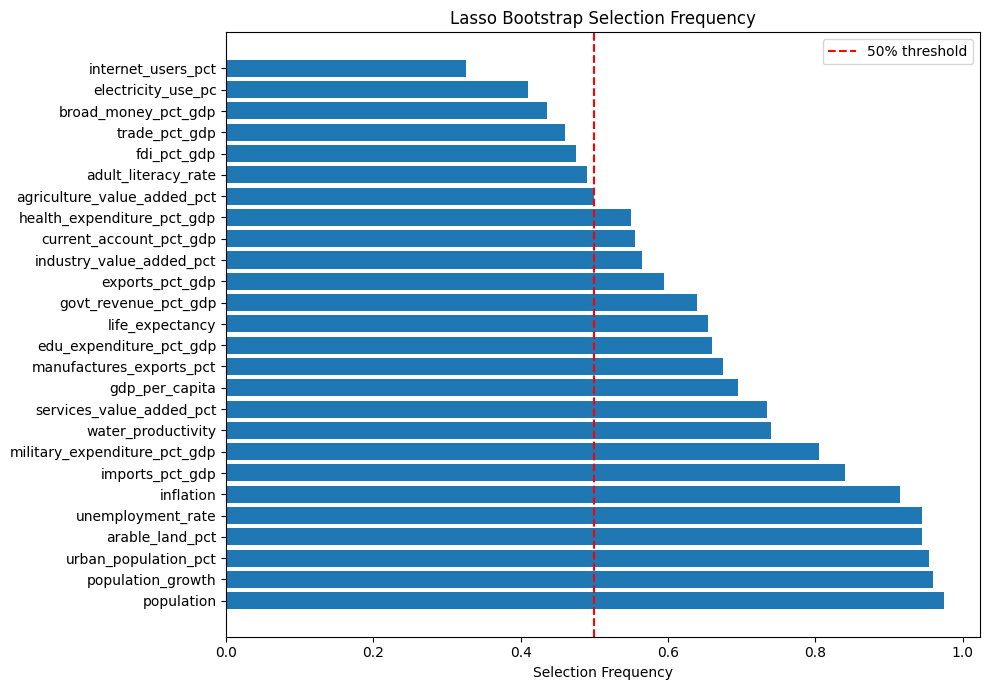

In [27]:
from sklearn.linear_model import LassoCV
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Bootstrap resampling to compute Lasso selection frequency
n_bootstraps = 200
selection_counts = np.zeros(len(feature_cols))

for i in range(n_bootstraps):
    # Draw bootstrap resample
    idx = np.random.choice(len(X_train_scaled), size=len(X_train_scaled), replace=True)
    X_boot = X_train_scaled.iloc[idx].values
    y_boot = y_train_reg.iloc[idx].values

    # Fit LassoCV on resample
    lasso_boot = LassoCV(cv=5, random_state=42)
    lasso_boot.fit(X_boot, y_boot)

    # Record non-zero coefficients
    selection_counts += (lasso_boot.coef_ != 0).astype(int)

# Compute selection frequency
selection_freq = selection_counts / n_bootstraps
freq_df = pd.DataFrame({'Feature': feature_cols, 'Selection Frequency': selection_freq})
freq_df = freq_df.sort_values('Selection Frequency', ascending=False)

print(freq_df.to_string(index=False))

# Plot horizontal bar chart
plt.figure(figsize=(10, 7))
plt.barh(freq_df['Feature'], freq_df['Selection Frequency'])
plt.axvline(0.5, color='red', linestyle='--', label='50% threshold')
plt.xlabel('Selection Frequency')
plt.title('Lasso Bootstrap Selection Frequency')
plt.legend()
plt.tight_layout()
plt.show()

The stable predictors which were selected in more than 80% of bootstrap resamples are pop, pop growth, urban pop pct, arable_land_pct, unemp rate, inflation, imports pct gdp, and military expenditure. The fragile predictors which were selected in less than 30% pf resamples is internet users at only 32.5%. Selection instability among the mid-tear predictors reflects high multicollinearity in the dataset. when correlated indicators comete for inclusion, the Lasso picks one depending on which countries happen to be in the sample which makes their selection frequencies unreliable.

## P.R.I.M.E. Prompt — Task 4.2: Cost-Sensitive Threshold Optimization

**Prep:** I am working in Python with a trained logistic regression classifier. I have predicted
probabilities for the test set (probs), true binary labels (y_test_cls), and the following
cost structure: a missed crisis (False Negative) costs 50 billion dollars, and a false alarm
(False Positive) costs 2 million dollars.

**Request:** Write a Python script that:
1. Sweeps thresholds from 0.01 to 0.99 in steps of 0.01.
2. At each threshold, computes the number of False Negatives and False Positives.
3. Computes total expected cost: FN * 50,000,000,000 + FP * 2,000,000.
4. Plots the expected cost curve as a function of threshold τ.
5. Identifies and annotates the cost-minimizing threshold on the plot.

**Iterate:** Use probs and y_test_cls as inputs. Label the y-axis in billions of dollars
for readability. Annotate the minimum cost point with both the threshold value and
the expected cost.

**Mechanism Check:** Add a comment explaining why the cost-minimizing threshold
differs from the F1-optimal threshold when costs are highly asymmetric.

**Evaluate:** Print the cost-minimizing threshold, the number of FNs and FPs at that
threshold, and the total expected cost in billions.

Cost-minimizing threshold: 0.01
False Negatives:           0
False Positives:           56
Total expected cost:       $0.11 billion


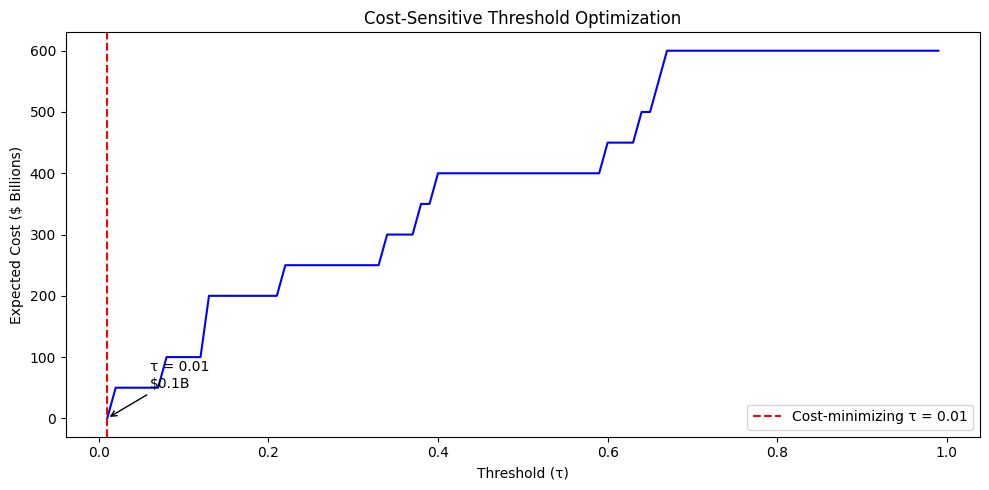

In [28]:
# Cost-sensitive threshold optimization
fn_cost = 50_000_000_000
fp_cost = 2_000_000

thresholds   = np.arange(0.01, 1.00, 0.01)
total_costs  = []
fn_counts    = []
fp_counts    = []

for t in thresholds:
    preds = (probs >= t).astype(int)
    fn = np.sum((preds == 0) & (y_test_cls == 1))
    fp = np.sum((preds == 1) & (y_test_cls == 0))
    total_costs.append(fn * fn_cost + fp * fp_cost)
    fn_counts.append(fn)
    fp_counts.append(fp)

# Find cost-minimizing threshold
min_idx      = np.argmin(total_costs)
min_tau      = thresholds[min_idx]
min_cost     = total_costs[min_idx]
min_fn       = fn_counts[min_idx]
min_fp       = fp_counts[min_idx]

print(f"Cost-minimizing threshold: {min_tau:.2f}")
print(f"False Negatives:           {min_fn}")
print(f"False Positives:           {min_fp}")
print(f"Total expected cost:       ${min_cost / 1e9:.2f} billion")

# Plot expected cost curve
plt.figure(figsize=(10, 5))
plt.plot(thresholds, [c / 1e9 for c in total_costs], color='blue')
plt.axvline(min_tau, color='red', linestyle='--', label=f'Cost-minimizing τ = {min_tau:.2f}')
plt.annotate(f'τ = {min_tau:.2f}\n${min_cost/1e9:.1f}B',
             xy=(min_tau, min_cost / 1e9),
             xytext=(min_tau + 0.05, min_cost / 1e9 + 50),
             arrowprops=dict(arrowstyle='->'))
plt.xlabel('Threshold (τ)')
plt.ylabel('Expected Cost ($ Billions)')
plt.title('Cost-Sensitive Threshold Optimization')
plt.legend()
plt.tight_layout()
plt.show()

The cost-minimizing threshold of τ = 0.01 is dramatically lower than both the F1-optimal threshold (0.27) and the capacity-constrained threshold (0.55) because the cost asymmetry is so extreme. One single missed crisis costs 50 billion dollars while while a false alarm costs only 2 million dollars, meaning the model needs to flag 25,000 false alarms to equal the cost of one missed crisis.

At τ = 0.01 the model flags nearly every country (56 false positives, 0 missed crises) for a total expected cost of only 0.11 billion dollars. The F1-optimal threshold balances precision and recall without any regard for dollar costs, and the capacity-constrained threshold prioritizes staffing limits over financial consequences.

Recommendation: The cost-minimizing threshold should be the benchmark, but pair it with the capacity constraint as an operational filter. Using the model's predicted probabilities to rank all flagged countries and deploy the 5 available missions to the highest-risk ones first.